In [83]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [85]:
import shlex

def _parse_flag(command, flag):
    """Extract the value of --flag from a command string. Returns None if absent."""
    parts = shlex.split(command)
    for i, p in enumerate(parts):
        if p == flag and i + 1 < len(parts):
            return parts[i + 1]
    return None


def load_run(log_path):
    """Parse a single task .out file → (config dict, list of eval dicts).

    Enriches config with 'lr' (from first eval event) and
    'lora_plus_multiplier' (from command string) since these aren't
    present in the config JSON event.
    """
    config, evals = None, []
    for line in Path(log_path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        if obj.get("event") == "config":
            config = obj
        elif obj.get("event") == "eval":
            evals.append(obj)
    if config is not None and evals:
        config.setdefault("lr", evals[0]["lr"])
        lp = _parse_flag(config["command"], "--lora_plus_multiplier")
        config.setdefault("lora_plus_multiplier", float(lp) if lp else 1.0)
    return config, evals


def load_sweep(group):
    """Load all runs for a sweep group. Returns list of (config, evals) tuples."""
    log_dir = Path(f"../logs/{group}/run_info/logs")
    runs = []
    for f in sorted(log_dir.glob("*.out")):
        config, evals = load_run(f)
        if config is not None and evals:
            runs.append((config, evals))
    return runs

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [86]:
lp_runs = load_sweep("loraplus_2k_1ep")
print(f"Loaded {len(lp_runs)} runs")
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0]["lr"], x[0].get("lora_plus_multiplier", 1))):
    lr = cfg["lr"]
    m = cfg.get("lora_plus_multiplier", 1.0)
    print(f"  η={lr:.0e}  m={m:.0f}  steps={[e['step'] for e in evs]}")

Loaded 6 runs
  η=1e-04  m=1  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=1e-04  m=4  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=1e-04  m=16  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=1  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=4  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]
  η=3e-04  m=16  steps=[200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]


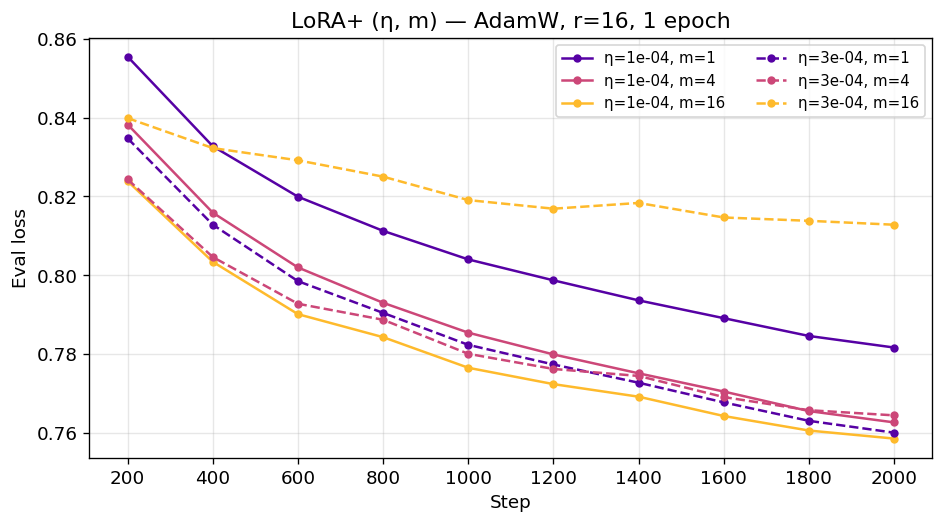

In [87]:
fig, ax = plt.subplots(figsize=(8, 4.5))

m_colors = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}
lr_styles = {1e-4: "-", 3e-4: "--"}

for cfg, evs in sorted(lp_runs, key=lambda x: (x[0]["lr"], x[0].get("lora_plus_multiplier", 1))):
    lr = cfg["lr"]
    m = int(round(cfg.get("lora_plus_multiplier", 1.0)))
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ls = lr_styles.get(lr, "-")
    color = m_colors.get(m, "grey")
    label = f"η={lr:.0e}, m={m}"
    ax.plot(steps, losses, ls=ls, color=color, marker="o", markersize=4, label=label)

ax.set_xlabel("Step")
ax.set_ylabel("Eval loss")
ax.legend(ncol=2, fontsize=9)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.grid(True, alpha=0.3)
ax.set_title("LoRA+ (η, m) — AdamW, r=16, 1 epoch")
fig.tight_layout()
plt.show()

## Optimizer comparison — η=3e-4, m=1, r=16, 1 epoch

In [88]:
OPTIM_COLORS = {
    "adamw": "#1f77b4",
    "scaled-lora": "#ff7f0e",
    "lin-lora": "#2ca02c",
    "adam-scaled-lora": "#d62728",
    "adam-lin-lora": "#9467bd",
}

# Use the longest completed run (2k subsumes 500 with constant LR)
oc2k_log = Path("../logs/optim_compare_2k_1ep/run_info/logs")
if oc2k_log.exists():
    oc_runs = load_sweep("optim_compare_2k_1ep")
    oc_label = "2000 steps"
else:
    oc_runs = load_sweep("optim_compare_500_1ep")
    oc_label = "500 steps (2k pending)"

print(f"Loaded {len(oc_runs)} runs ({oc_label})")
for cfg, evs in sorted(oc_runs, key=lambda x: x[0]["optimizer"]):
    print(f"  {cfg['optimizer']:20s}  steps through {evs[-1]['step']}")

Loaded 5 runs (2000 steps)
  adam-lin-lora         steps through 2000
  adam-scaled-lora      steps through 2000
  adamw                 steps through 2000
  lin-lora              steps through 2000
  scaled-lora           steps through 2000


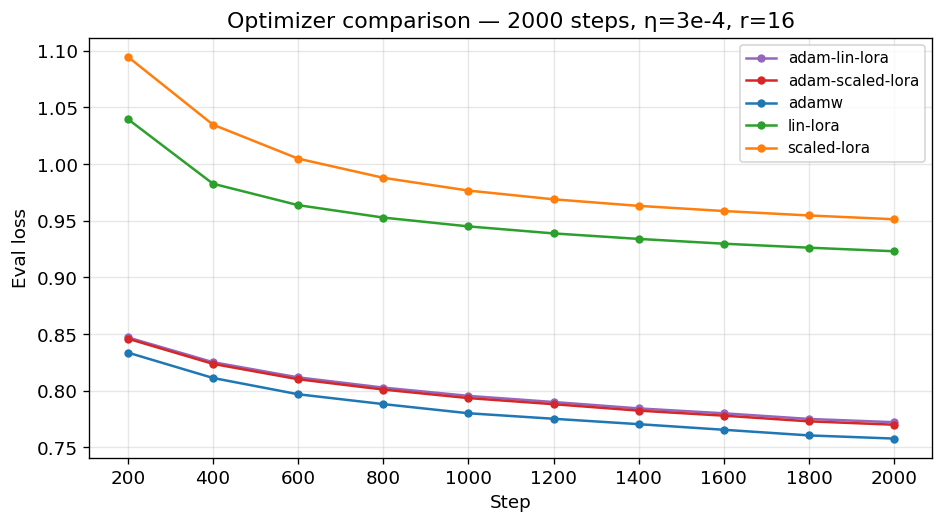

In [89]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for cfg, evs in sorted(oc_runs, key=lambda x: x[0]["optimizer"]):
    opt = cfg["optimizer"]
    steps = [e["step"] for e in evs]
    losses = [e["eval_loss"] for e in evs]
    ax.plot(steps, losses, color=OPTIM_COLORS.get(opt, "grey"),
            marker="o", markersize=4, label=opt)

ax.set_xlabel("Step")
ax.set_ylabel("Eval loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200 if oc_label.startswith("2000") else 100))
ax.set_title(f"Optimizer comparison — {oc_label}, η=3e-4, r=16")
fig.tight_layout()
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [90]:
svd_runs = load_sweep("svd_sweep_2k_1ep")
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    mode = cfg["training_mode"]
    lr = cfg["lr"]
    proj = cfg.get("svd_projection", "?")
    last = evs[-1]["step"]
    el = evs[-1]["eval_loss"]
    print(f"  {mode:<25s}  η={lr:.0e}  {proj}  steps through {last}  eval_loss={el:.4f}")

Loaded 8 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  randomized_niter4  steps through 400  eval_loss=0.8434
  svd_cumulative_oracle      η=1e-04  randomized_niter4  steps through 400  eval_loss=0.8248
  svd_cumulative_oracle      η=3e-04  randomized_niter4  steps through 400  eval_loss=0.9696
  svd_cumulative_oracle      η=1e-03  randomized_niter4  steps through 400  eval_loss=4.5820
  svd_step_oracle            η=3e-05  randomized_niter4  steps through 600  eval_loss=0.8953
  svd_step_oracle            η=1e-04  randomized_niter4  steps through 400  eval_loss=0.8392
  svd_step_oracle            η=3e-04  randomized_niter4  steps through 400  eval_loss=0.8886
  svd_step_oracle            η=1e-03  randomized_niter4  steps through 400  eval_loss=4.2297


  [filtered] svd_step_oracle  η=1e-03  final_eval_loss=4.2297
  [filtered] svd_cumulative_oracle  η=1e-03  final_eval_loss=4.5820


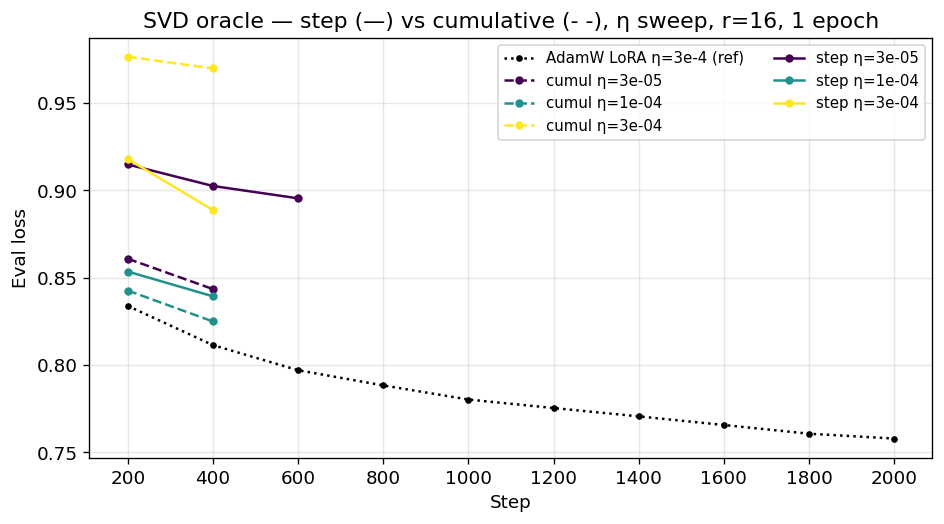

In [91]:
DIVERGE_THRESHOLD = 1.5  # drop runs whose final eval_loss exceeds this

if not svd_runs:
    print("No SVD oracle results yet — rerun after svd_sweep_2k_1ep completes.")
else:
    converged = [(cfg, evs) for cfg, evs in svd_runs if evs[-1]["eval_loss"] < DIVERGE_THRESHOLD]
    diverged  = [(cfg, evs) for cfg, evs in svd_runs if evs[-1]["eval_loss"] >= DIVERGE_THRESHOLD]
    for cfg, evs in diverged:
        print(f"  [filtered] {cfg['training_mode']}  η={cfg['lr']:.0e}  "
              f"final_eval_loss={evs[-1]['eval_loss']:.4f}")

    LRS = sorted({cfg["lr"] for cfg, _ in converged})
    lr_colors = {lr: plt.cm.viridis(i / max(len(LRS) - 1, 1)) for i, lr in enumerate(LRS)}
    mode_ls = {"svd_step_oracle": "-", "svd_cumulative_oracle": "--"}

    adamw_ref = [(cfg, evs) for cfg, evs in oc_runs if cfg["optimizer"] == "adamw"]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    if adamw_ref:
        cfg_ref, evs_ref = adamw_ref[0]
        ax.plot([e["step"] for e in evs_ref], [e["eval_loss"] for e in evs_ref],
                color="black", lw=1.5, ls=":", marker="o", markersize=3,
                label="AdamW LoRA η=3e-4 (ref)")

    for cfg, evs in sorted(converged, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
        mode = cfg["training_mode"]
        lr = cfg["lr"]
        steps = [e["step"] for e in evs]
        losses = [e["eval_loss"] for e in evs]
        short = "step" if "step" in mode else "cumul"
        ax.plot(steps, losses,
                color=lr_colors[lr], ls=mode_ls[mode],
                marker="o", markersize=4,
                label=f"{short} η={lr:.0e}")

    ax.set_xlabel("Step")
    ax.set_ylabel("Eval loss")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.set_title("SVD oracle — step (—) vs cumulative (- -), η sweep, r=16, 1 epoch")
    fig.tight_layout()
    plt.show()